# Введение в Google Colab. Работа с нейронными сетями

Практическая работа № 1 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Задание** из методических указаний: освоить среду Google Colab, подключить Google Диск,
импортировать библиотеки TensorFlow, Keras, NumPy, Matplotlib и scikit-learn, загрузить набор
рукописных цифр MNIST, разбить его по своему варианту и вывести изображение с меткой.
Дополнительно проверяю, какие вычислительные устройства доступны, и запускаю первую простую сеть.

Ноутбук написан так, чтобы работать и в Colab, и локально: ячейки, которые нужны только в Colab
(подключение Диска), сами определяют, где запущены. Скриншоты работы в интерфейсе Colab
приведены в отчёте.

## 1. Среда выполнения

Проверяю версии Python и библиотек и то, где запущен ноутбук. В Colab модуль `google.colab`
импортируется, локально нет.

In [1]:
import os
import sys
import platform

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('Где запущено:', 'Google Colab' if IN_COLAB else 'локально')
print('Python:', sys.version.split()[0])
print('Система:', platform.system(), platform.release(), platform.machine())

Где запущено: локально
Python: 3.12.11
Система: Darwin 25.6.0 arm64


## 2. Подключение Google Диска

В Colab блокноты сохраняются на Google Диск в папку `Colab Notebooks`. Чтобы читать и писать файлы
с Диска, его нужно подключить и перейти в эту папку. Локально этот шаг пропускается.

In [2]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/Colab Notebooks')
else:
    print('Локальный запуск: Google Диск не подключаю, работаю в текущей папке')
print('Текущая папка:', os.getcwd())

Локальный запуск: Google Диск не подключаю, работаю в текущей папке
Текущая папка: /Users/f.arutyunyan/Documents/personal/mospolytech/mmo/prac1


## 3. Импорт библиотек

Основная библиотека курса TensorFlow, внутри неё Keras, который позволяет собрать и обучить
нейронную сеть в несколько строк. NumPy нужен для массивов, Matplotlib для графиков,
scikit-learn для разбиения выборки и метрик.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from tensorflow import keras

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('NumPy:', np.__version__)
print('scikit-learn:', sklearn.__version__)

os.makedirs('figures', exist_ok=True)

TensorFlow: 2.21.0
Keras: 3.15.1
NumPy: 2.5.3
scikit-learn: 1.9.1


## 4. Вычислительные устройства

Главное преимущество Colab бесплатный доступ к графическому процессору. Проверяю,
какие устройства видит TensorFlow. В Colab GPU включается через меню
«Среда выполнения» → «Сменить среду выполнения» → «Графический процессор».

In [4]:
devices = tf.config.list_physical_devices()
gpus = tf.config.list_physical_devices('GPU')
for d in devices:
    print(d.device_type, d.name)
print('Графический процессор доступен' if gpus else 'Графического процессора нет, вычисления на CPU')

CPU /physical_device:CPU:0
Графического процессора нет, вычисления на CPU


## 5. Набор данных MNIST

MNIST это 70 000 изображений рукописных цифр 28 на 28 пикселей, яркость от 0 до 255.
Keras загружает его сразу разбитым 60 000 на 10 000, но это разбиение одинаковое у всех.
По методичке объединяю обе части и разбиваю заново случайным образом со своим `random_state`.
Номер в списке группы у меня 1, его и беру: так у каждого студента своя выборка.

In [5]:
from keras.datasets import mnist
from sklearn.model_selection import train_test_split

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

VARIANT = 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, train_size=60000, random_state=VARIANT)

print('Shape of X train:', X_train.shape)
print('Shape of y train:', y_train.shape)
print('Shape of X test:', X_test.shape)
print('Shape of y test:', y_test.shape)

Shape of X train: (60000, 28, 28)
Shape of y train: (60000,)
Shape of X test: (10000, 28, 28)
Shape of y test: (10000,)


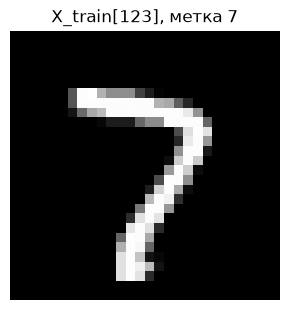

Метка изображения: 7


In [6]:
# изображение из методички: элемент с индексом 123
plt.figure(figsize=(3.5, 3.5))
plt.imshow(X_train[123], cmap=plt.get_cmap('gray'))
plt.title(f'X_train[123], метка {y_train[123]}')
plt.axis('off')
plt.savefig('figures/01_x_train_123.png', dpi=150, bbox_inches='tight')
plt.show()
print('Метка изображения:', y_train[123])

**Рисунок 1 — Изображение X_train[123] из моего разбиения**

В моём разбиении с random_state = 1 под индексом 123 оказалась цифра 7, а не пример из методички: так и должно быть, у каждого студента своя выборка.

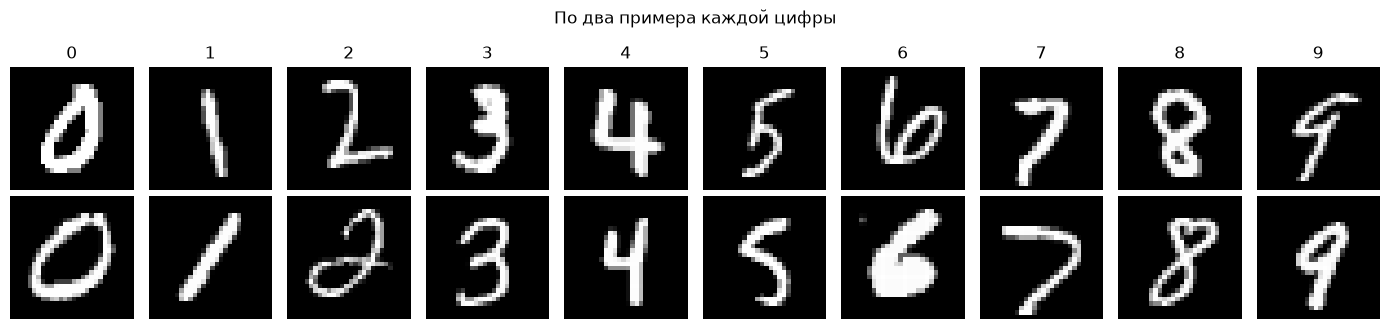

Изображений каждой цифры в обучающей части: {0: 5944, 1: 6691, 2: 5955, 3: 6110, 4: 5883, 5: 5383, 6: 5934, 7: 6243, 8: 5889, 9: 5968}


In [7]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.4))
for digit in range(10):
    idx = np.where(y_train == digit)[0][:2]
    for row, i in enumerate(idx):
        axes[row, digit].imshow(X_train[i], cmap='gray')
        axes[row, digit].axis('off')
    axes[0, digit].set_title(str(digit))
fig.suptitle('По два примера каждой цифры')
fig.tight_layout()
plt.savefig('figures/02_digits.png', dpi=150, bbox_inches='tight')
plt.show()

counts = np.bincount(y_train)
print('Изображений каждой цифры в обучающей части:', dict(enumerate(counts.tolist())))

**Рисунок 2 — Примеры каждой цифры**

Цифры пишутся очень по-разному, а классы почти сбалансированы: от 5383 пятёрок до 6691 единицы в обучающей части.

## 6. Первая нейронная сеть

Чтобы проверить, что среда полностью рабочая, обучаю простейшую сеть: изображение разворачивается
в вектор из 784 чисел, один скрытый слой из 128 нейронов с активацией ReLU и выходной слой
из 10 нейронов с softmax. Яркость пикселей делю на 255, чтобы входы были от 0 до 1.

In [8]:
tf.keras.utils.set_random_seed(VARIANT)

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_train / 255.0, y_train, epochs=5, batch_size=128,
                    validation_split=0.1, verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

...

422/422 - 0s - 1ms/step - accuracy: 0.9660 - loss: 0.1198 - val_accuracy: 0.9660 - val_loss: 0.1194


Epoch 4/5


422/422 - 0s - 996us/step - accuracy: 0.9735 - loss: 0.0930 - val_accuracy: 0.9695 - val_loss: 0.1059


Epoch 5/5


422/422 - 0s - 1ms/step - accuracy: 0.9787 - loss: 0.0751 - val_accuracy: 0.9710 - val_loss: 0.0984


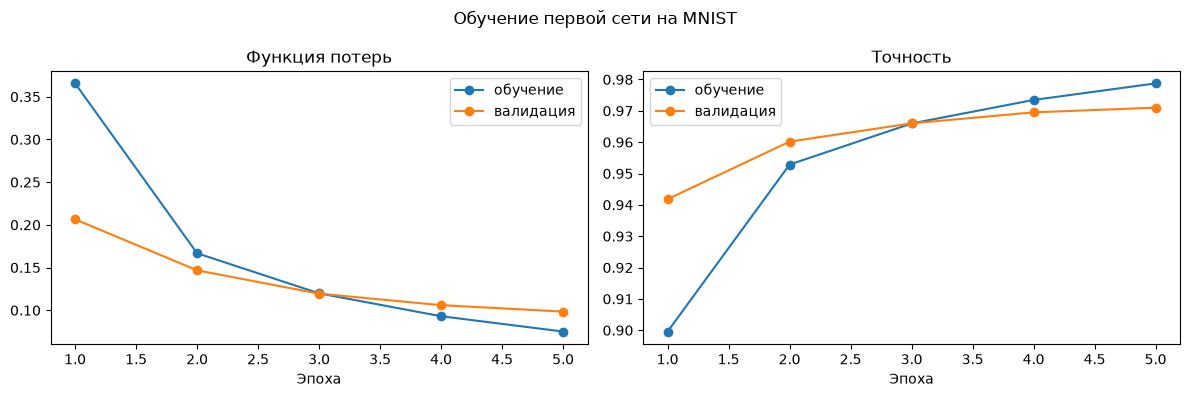

Точность на тесте: 0.9680, ошибка: 0.1060


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history.history['loss']) + 1)
axes[0].plot(ep, history.history['loss'], 'o-', label='обучение')
axes[0].plot(ep, history.history['val_loss'], 'o-', label='валидация')
axes[0].set_title('Функция потерь')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[1].plot(ep, history.history['accuracy'], 'o-', label='обучение')
axes[1].plot(ep, history.history['val_accuracy'], 'o-', label='валидация')
axes[1].set_title('Точность')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
fig.suptitle('Обучение первой сети на MNIST')
fig.tight_layout()
plt.savefig('figures/03_training.png', dpi=150, bbox_inches='tight')
plt.show()

test_loss, test_acc = model.evaluate(X_test / 255.0, y_test, verbose=0)
print(f'Точность на тесте: {test_acc:.4f}, ошибка: {test_loss:.4f}')

**Рисунок 3 — Кривые обучения первой сети**

Уже после первой эпохи точность на валидации 0,942, к пятой 0,971, кривые идут рядом, то есть сеть обучается без переобучения.

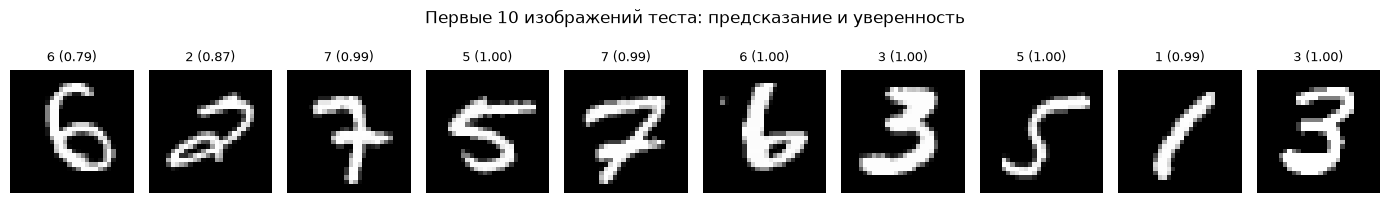

Настоящие метки: [6, 2, 7, 5, 7, 6, 3, 5, 1, 3]
Предсказания:   [6, 2, 7, 5, 7, 6, 3, 5, 1, 3]


In [10]:
probs = model.predict(X_test[:10] / 255.0, verbose=0)
fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))
for k, ax in enumerate(axes):
    ax.imshow(X_test[k], cmap='gray')
    ax.axis('off')
    ax.set_title(f'{probs[k].argmax()} ({probs[k].max():.2f})', fontsize=9,
                 color='black' if probs[k].argmax() == y_test[k] else 'red')
fig.suptitle('Первые 10 изображений теста: предсказание и уверенность')
fig.tight_layout()
plt.savefig('figures/04_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Настоящие метки:', y_test[:10].tolist())
print('Предсказания:  ', probs.argmax(axis=1).tolist())

**Рисунок 4 — Распознавание первых десяти изображений тестовой выборки**

Все десять первых изображений теста распознаны верно, а на всей тестовой выборке точность 0,9680.

## 7. Выводы

1. **Среда.** Ноутбук работает и в Colab, и локально: ячейки определяют, где запущены, и подключают
   Google Диск только в Colab. Локальный запуск: Python 3.12, TensorFlow 2.21, Keras 3.15, NumPy 2.5,
   scikit-learn 1.9 на Mac с процессором Apple M4. Графический процессор TensorFlow на Mac не видит,
   вычисления идут на CPU; в Colab GPU включается в настройках среды выполнения.

2. **Данные.** MNIST загружен через Keras, 70 000 изображений 28 на 28. Обе части объединены и заново
   разбиты 60 000 на 10 000 с random_state = 1 по номеру в списке группы, поэтому выборка своя.
   Изображение X_train[123] в моём разбиении это цифра 7.

3. **Первая сеть.** Один скрытый слой из 128 нейронов, 101 770 параметров, 5 эпох. Точность
   на валидации выросла с 0,942 после первой эпохи до 0,971 после пятой, на тесте 0,9680, ошибка 0,1060.
   Все первые десять тестовых изображений распознаны верно.

4. **Вывод по среде.** Colab удобен тем, что библиотеки уже установлены и есть бесплатный GPU,
   но сессия обрывается после простоя и данные нужно хранить на Диске. Локальная среда стабильнее,
   но библиотеки приходится ставить и согласовывать версии самому.